In [98]:
import pandas as pd
import numpy as np

# =========================================================
# DATA HANDLING
# =========================================================
import numpy as np
import pandas as pd

# =========================================================
# VISUALIZATION
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# MACHINE LEARNING
# =========================================================
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# =========================================================
# IMBALANCED DATA
# =========================================================
from imblearn.over_sampling import SMOTE

# =========================================================
# EVALUATION
# =========================================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# =========================================================
# STATISTICS
# =========================================================
from scipy.stats import chi2_contingency

# =========================================================
# SETTINGS
# =========================================================
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

In [38]:
df = pd.read_excel("final_df.xlsx")
df

,vaccinated,vaccinated_5class,vaccinated_9class,antenatal_visits_yes,institutional_delivery,birth_order,mothers_age_gt_35,residence_urban,media_exposure,child_age_months,highest_educational_level,wealth_index,recieves_icds_benefits,facility_distance_issue,has_automobile,health_worker_visit,bcg,dpt1,polio1,dpt2,polio2,dpt3,polio3,measles1,pentavalent1,pentavalent2,pentavalent3,state,respondent_age,antenatal_visits,place_of_delivery,child_sex,has_motorcycle,has_car_truck,reads_newspaper,listens_radio,watches_tv,household_sex_female,sample_weight,psu,strata
0,1,4,8,1,1,4,0,0,0,13,1,3,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,35,5,21,2,0,0,0,0,0,0,196628,109,121
1,1,4,8,1,1,2,0,0,1,12,2,5,0,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,30,8,21,2,0,1,0,1,1,0,204798,140,121
2,1,4,8,1,1,3,1,0,0,12,2,3,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,37,10,24,1,0,0,0,0,0,0,220211,102,121
3,1,4,8,1,1,1,0,0,0,16,2,4,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,27,7,21,2,0,1,0,0,0,0,303213,133,122
4,1,4,8,1,1,2,0,0,1,20,0,2,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,34,10,21,1,0,0,0,1,0,0,352749,118,123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12372,0,0,0,1,1,1,0,1,1,15,3,3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,37,28,4,21,2,1,0,2,1,0,0,39833,319,31
12373,1,4,8,1,1,2,0,1,1,21,2,4,0,1,1,0,1,1,1,1,1,1,1,1,1,1,1,37,33,9,21,2,0,1,1,2,2,0,38490,315,31
12374,1,4,8,1,1,3,0,0,1,16,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,37,28,4,21,2,0,1,0,2,1,0,54986,423,423
12375,1,4,8,0,1,3,1,0,1,13,0,2,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,37,38,1,24,1,0,0,0,0,1,0,50766,435,423


In [39]:
# Shape
print(df.shape)

# Column names
print(df.columns)

# Data types
df.info()

# Null Values
print(df.isnull().sum())

(12377, 41)
Index(['vaccinated', 'vaccinated_5class', 'vaccinated_9class',
       'antenatal_visits_yes', 'institutional_delivery', 'birth_order',
       'mothers_age_gt_35', 'residence_urban', 'media_exposure',
       'child_age_months', 'highest_educational_level', 'wealth_index',
       'recieves_icds_benefits', 'facility_distance_issue', 'has_automobile',
       'health_worker_visit', 'bcg', 'dpt1', 'polio1', 'dpt2', 'polio2',
       'dpt3', 'polio3', 'measles1', 'pentavalent1', 'pentavalent2',
       'pentavalent3', 'state', 'respondent_age', 'antenatal_visits',
       'place_of_delivery', 'child_sex', 'has_motorcycle', 'has_car_truck',
       'reads_newspaper', 'listens_radio', 'watches_tv',
       'household_sex_female', 'sample_weight', 'psu', 'strata'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12377 entries, 0 to 12376
Data columns (total 41 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     ----------

In [40]:
counts = df["vaccinated"].value_counts()
percent = df["vaccinated"].value_counts(normalize=True)


result = pd.concat([counts, percent], axis=1, keys=['Count', 'Percentage'])
print(result)

            Count  Percentage
vaccinated                   
1            7804    0.630524
0            4573    0.369476


In [41]:
features = [
    'antenatal_visits_yes',
    'institutional_delivery',
    'birth_order',
    'mothers_age_gt_35',
    'residence_urban',
    'media_exposure',
    'child_age_months',
    'highest_educational_level',
    'wealth_index',
    'recieves_icds_benefits',
    'facility_distance_issue',
    'has_automobile',
    'health_worker_visit'
]

target = 'vaccinated'

df_model = df[features + [target]]

df_model

,antenatal_visits_yes,institutional_delivery,birth_order,mothers_age_gt_35,residence_urban,media_exposure,child_age_months,highest_educational_level,wealth_index,recieves_icds_benefits,facility_distance_issue,has_automobile,health_worker_visit,vaccinated
0,1,1,4,0,0,0,13,1,3,1,1,0,1,1
1,1,1,2,0,0,1,12,2,5,0,0,1,0,1
2,1,1,3,1,0,0,12,2,3,1,1,0,0,1
3,1,1,1,0,0,0,16,2,4,1,1,1,0,1
4,1,1,2,0,0,1,20,0,2,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12372,1,1,1,0,1,1,15,3,3,0,0,1,0,0
12373,1,1,2,0,1,1,21,2,4,0,1,1,0,1
12374,1,1,3,0,0,1,16,0,1,0,1,1,1,1
12375,0,1,3,1,0,1,13,0,2,0,1,0,1,1


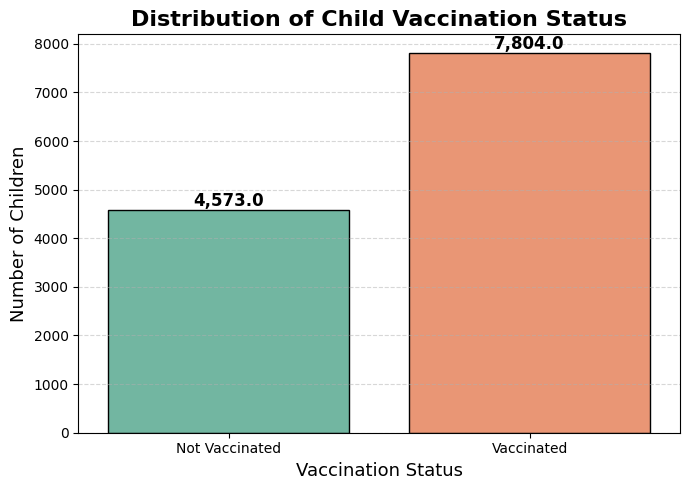

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count values
counts = df_model['vaccinated'].value_counts()

# Create figure
plt.figure(figsize=(7,5))

# Better styled countplot
ax = sns.countplot(
    x='vaccinated',
    data=df_model,
    palette='Set2',
    edgecolor='black'
)

# Add count labels on bars
for p in ax.patches:

    height = p.get_height()

    ax.annotate(
        f'{height:,}',
        (p.get_x() + p.get_width()/2, height),
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

# Titles and labels
plt.title(
    "Distribution of Child Vaccination Status",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    "Vaccination Status",
    fontsize=13
)

plt.ylabel(
    "Number of Children",
    fontsize=13
)

# Rename x-axis labels
ax.set_xticklabels([
    'Not Vaccinated',
    'Vaccinated'
])

# Grid for readability
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()

plt.show()

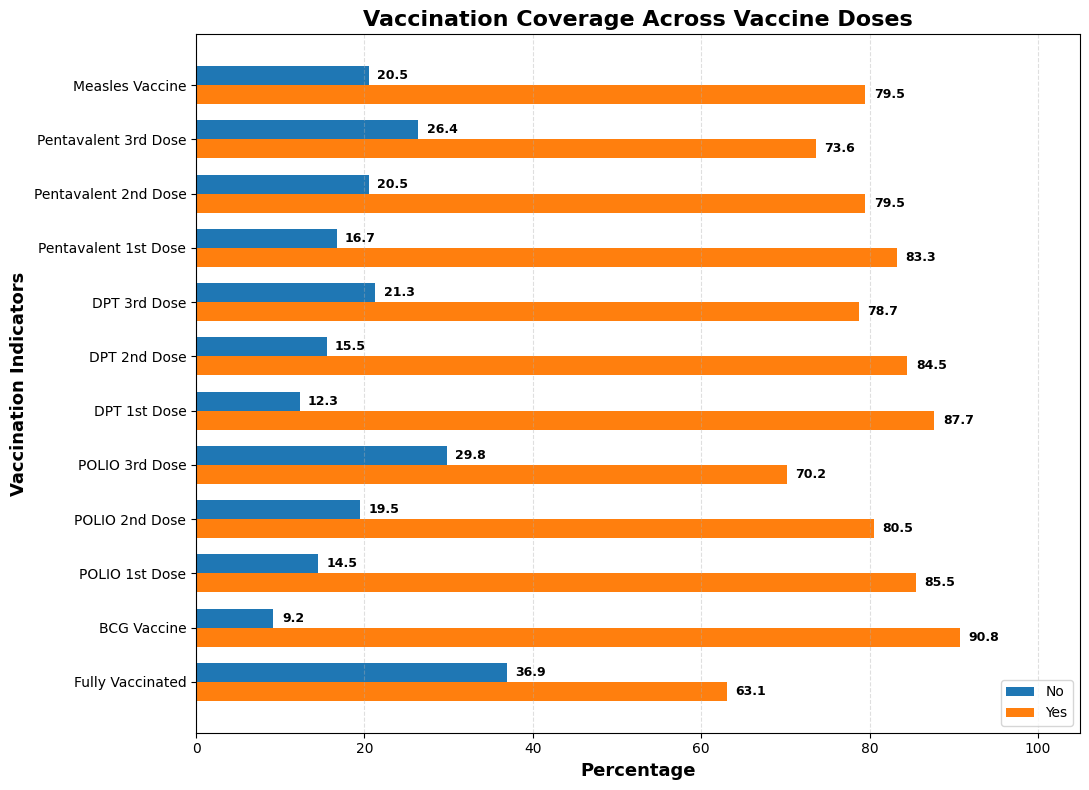

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# VACCINATION VARIABLES IN REQUIRED ORDER
# =========================================================

vaccine_cols = [

    'vaccinated',

    'bcg',

    'polio1',
    'polio2',
    'polio3',

    'dpt1',
    'dpt2',
    'dpt3',

    'pentavalent1',
    'pentavalent2',
    'pentavalent3',

    'measles1'
]

# =========================================================
# LABELS
# =========================================================

labels = [

    'Fully Vaccinated',

    'BCG Vaccine',

    'POLIO 1st Dose',
    'POLIO 2nd Dose',
    'POLIO 3rd Dose',

    'DPT 1st Dose',
    'DPT 2nd Dose',
    'DPT 3rd Dose',

    'Pentavalent 1st Dose',
    'Pentavalent 2nd Dose',
    'Pentavalent 3rd Dose',

    'Measles Vaccine'
]

# =========================================================
# CALCULATE YES / NO PERCENTAGES
# =========================================================

yes_percent = []
no_percent = []

for col in vaccine_cols:

    yes = df[col].mean() * 100

    no = 100 - yes

    yes_percent.append(round(yes,1))

    no_percent.append(round(no,1))

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(11,8))

y = np.arange(len(labels))

bar_height = 0.35

# =========================================================
# NO BARS
# =========================================================

plt.barh(
    y + bar_height/2,
    no_percent,
    height=bar_height,
    label='No'
)

# =========================================================
# YES BARS
# =========================================================

plt.barh(
    y - bar_height/2,
    yes_percent,
    height=bar_height,
    label='Yes'
)

# =========================================================
# ADD PERCENT LABELS
# =========================================================

for i in range(len(labels)):

    # YES labels
    plt.text(
        yes_percent[i] + 1,
        i - bar_height/2,
        f"{yes_percent[i]}",
        va='center',
        fontsize=9,
        fontweight='bold'
    )

    # NO labels
    plt.text(
        no_percent[i] + 1,
        i + bar_height/2,
        f"{no_percent[i]}",
        va='center',
        fontsize=9,
        fontweight='bold'
    )

# =========================================================
# AXES LABELS
# =========================================================

plt.yticks(
    y,
    labels,
    fontsize=10
)

plt.xlabel(
    "Percentage",
    fontsize=13,
    fontweight='bold'
)

plt.ylabel(
    "Vaccination Indicators",
    fontsize=13,
    fontweight='bold'
)

# =========================================================
# TITLE
# =========================================================

plt.title(
    "Vaccination Coverage Across Vaccine Doses",
    fontsize=16,
    fontweight='bold'
)

# =========================================================
# LEGEND
# =========================================================

plt.legend(
    loc='lower right',
    fontsize=10
)

# =========================================================
# GRID
# =========================================================

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

# =========================================================
# LIMIT
# =========================================================

plt.xlim(0, 105)

# =========================================================
# LAYOUT
# =========================================================

plt.tight_layout()

plt.show()

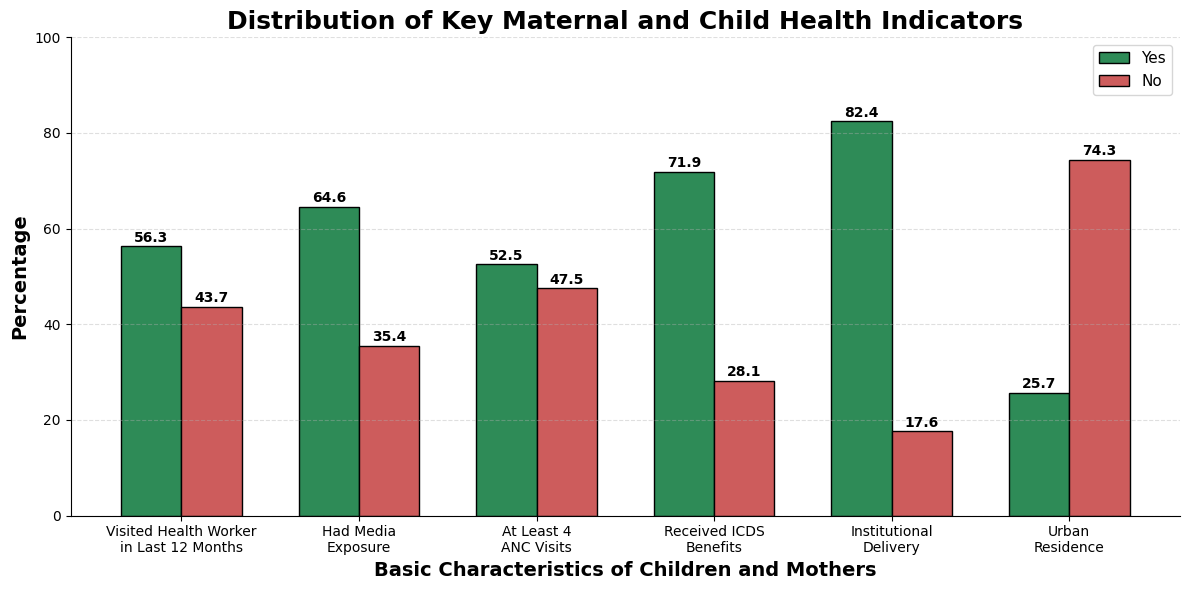

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================================================
# SELECTED VARIABLES
# =========================================================

selected_vars = [

    'health_worker_visit',

    'media_exposure',

    'antenatal_visits_yes',

    'recieves_icds_benefits',

    'institutional_delivery',

    'residence_urban'
]

# =========================================================
# LABELS
# =========================================================

labels = [

    'Visited Health Worker\nin Last 12 Months',

    'Had Media\nExposure',

    'At Least 4\nANC Visits',

    'Received ICDS\nBenefits',

    'Institutional\nDelivery',

    'Urban\nResidence'
]

# =========================================================
# CALCULATE YES / NO PERCENTAGES
# =========================================================

yes_percent = []
no_percent = []

for col in selected_vars:

    yes = df[col].mean() * 100

    no = 100 - yes

    yes_percent.append(round(yes,1))

    no_percent.append(round(no,1))

# =========================================================
# BAR POSITIONS
# =========================================================

x = np.arange(len(labels))

width = 0.34

# =========================================================
# FIGURE
# =========================================================

plt.figure(figsize=(12,6))

# =========================================================
# CUSTOM COLORS
# =========================================================

yes_color = '#2E8B57'   # Sea Green

no_color = '#CD5C5C'    # Indian Red

# =========================================================
# YES BARS
# =========================================================

bars1 = plt.bar(

    x - width/2,

    yes_percent,

    width,

    color=yes_color,

    edgecolor='black',

    label='Yes'
)

# =========================================================
# NO BARS
# =========================================================

bars2 = plt.bar(

    x + width/2,

    no_percent,

    width,

    color=no_color,

    edgecolor='black',

    label='No'
)

# =========================================================
# VALUE LABELS
# =========================================================

for bar in bars1:

    height = bar.get_height()

    plt.text(

        bar.get_x() + bar.get_width()/2,

        height + 1,

        f'{height:.1f}',

        ha='center',

        fontsize=10,

        fontweight='bold'
    )

for bar in bars2:

    height = bar.get_height()

    plt.text(

        bar.get_x() + bar.get_width()/2,

        height + 1,

        f'{height:.1f}',

        ha='center',

        fontsize=10,

        fontweight='bold'
    )

# =========================================================
# AXES LABELS
# =========================================================

plt.xticks(

    x,

    labels,

    fontsize=10
)

plt.ylabel(

    "Percentage",

    fontsize=14,

    fontweight='bold'
)

plt.xlabel(

    "Basic Characteristics of Children and Mothers",

    fontsize=14,

    fontweight='bold'
)

# =========================================================
# TITLE
# =========================================================

plt.title(

    "Distribution of Key Maternal and Child Health Indicators",

    fontsize=18,

    fontweight='bold'
)

# =========================================================
# LEGEND
# =========================================================

plt.legend(
    fontsize=11
)

# =========================================================
# GRID
# =========================================================

plt.grid(

    axis='y',

    linestyle='--',

    alpha=0.4
)

# =========================================================
# LIMITS
# =========================================================

plt.ylim(0, 100)

# =========================================================
# REMOVE EXTRA BORDERS
# =========================================================

sns.despine()

# =========================================================
# LAYOUT
# =========================================================

plt.tight_layout()

plt.show()

In [45]:
print("Duplicate Rows :", df_model.duplicated().sum())

Duplicate Rows : 0


In [46]:
df.columns

Index(['vaccinated', 'vaccinated_5class', 'vaccinated_9class',
       'antenatal_visits_yes', 'institutional_delivery', 'birth_order',
       'mothers_age_gt_35', 'residence_urban', 'media_exposure',
       'child_age_months', 'highest_educational_level', 'wealth_index',
       'recieves_icds_benefits', 'facility_distance_issue', 'has_automobile',
       'health_worker_visit', 'bcg', 'dpt1', 'polio1', 'dpt2', 'polio2',
       'dpt3', 'polio3', 'measles1', 'pentavalent1', 'pentavalent2',
       'pentavalent3', 'state', 'respondent_age', 'antenatal_visits',
       'place_of_delivery', 'child_sex', 'has_motorcycle', 'has_car_truck',
       'reads_newspaper', 'listens_radio', 'watches_tv',
       'household_sex_female', 'sample_weight', 'psu', 'strata'],
      dtype='object')

In [47]:
for col in df.columns:
    print("\n" + "="*50)
    print(f"Distribution of : {col}")
    print("="*50)
    
    # Frequency 
    counts = df[col].value_counts()
    
   
    percent = (df[col].value_counts(normalize=True) * 100).round(2)
    

    summary = pd.DataFrame({
        'Frequency': counts,
        'Percentage (%)': percent
    })
    
    print(summary)


Distribution of : vaccinated
            Frequency  Percentage (%)
vaccinated                           
1                7804           63.05
0                4573           36.95

Distribution of : vaccinated_5class
                   Frequency  Percentage (%)
vaccinated_5class                           
4                       7804           63.05
3                       1770           14.30
1                       1063            8.59
0                        916            7.40
2                        824            6.66

Distribution of : vaccinated_9class
                   Frequency  Percentage (%)
vaccinated_9class                           
8                       7804           63.05
7                       1155            9.33
0                        856            6.92
5                        847            6.84
6                        608            4.91
3                        370            2.99
4                        319            2.58
1                       

In [48]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12377 entries, 0 to 12376
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   antenatal_visits_yes       12377 non-null  int64
 1   institutional_delivery     12377 non-null  int64
 2   birth_order                12377 non-null  int64
 3   mothers_age_gt_35          12377 non-null  int64
 4   residence_urban            12377 non-null  int64
 5   media_exposure             12377 non-null  int64
 6   child_age_months           12377 non-null  int64
 7   highest_educational_level  12377 non-null  int64
 8   wealth_index               12377 non-null  int64
 9   recieves_icds_benefits     12377 non-null  int64
 10  facility_distance_issue    12377 non-null  int64
 11  has_automobile             12377 non-null  int64
 12  health_worker_visit        12377 non-null  int64
 13  vaccinated                 12377 non-null  int64
dtypes: int64(14)
memory us

In [49]:
df_model.describe()

,antenatal_visits_yes,institutional_delivery,birth_order,mothers_age_gt_35,residence_urban,media_exposure,child_age_months,highest_educational_level,wealth_index,recieves_icds_benefits,facility_distance_issue,has_automobile,health_worker_visit,vaccinated
count,12377.000000,12377.000000,12377.000000,12377.000000,12377.000000,12377.000000,12377.000000,12377.000000,12377.000000,12377.000000,12377.000000,12377.000000,12377.000000,12377.000000
mean,0.525168,0.823544,2.518138,0.068676,0.256767,0.646118,17.535429,1.427002,2.648622,0.718833,0.571625,0.492526,0.562657,0.630524
std,0.499386,0.381223,1.451048,0.252912,0.436867,0.478192,3.457947,1.029945,1.334638,0.449587,0.494863,0.499964,0.496079,0.482682
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,12.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,15.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,2.000000,0.000000,0.000000,1.000000,18.000000,2.000000,2.000000,1.000000,1.000000,0.000000,1.000000,1.000000
75%,1.000000,1.000000,3.000000,0.000000,1.000000,1.000000,21.000000,2.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,11.000000,1.000000,1.000000,1.000000,23.000000,3.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000


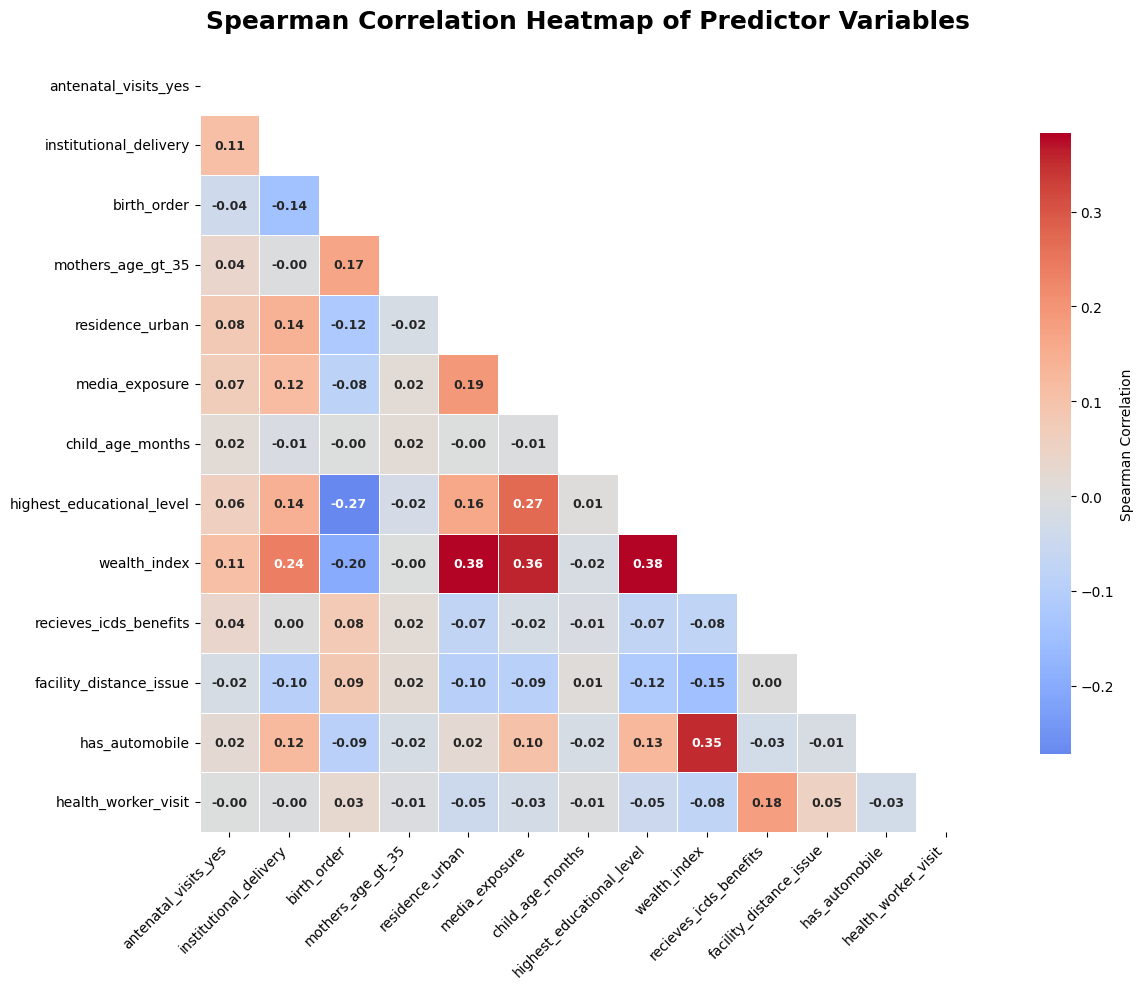

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================================================
# SPEARMAN CORRELATION MATRIX
# =========================================================

corr = df_model[features].corr(method='spearman')

# =========================================================
# MASK UPPER TRIANGLE
# =========================================================

mask = np.triu(
    np.ones_like(corr, dtype=bool)
)

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(14,10))

heatmap = sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={
        'shrink': 0.8,
        'label': 'Spearman Correlation'
    },
    annot_kws={
        'size': 9,
        'weight': 'bold'
    }
)

# =========================================================
# TITLES & LABELS
# =========================================================

plt.title(
    "Spearman Correlation Heatmap of Predictor Variables",
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xticks(
    rotation=45,
    ha='right',
    fontsize=10
)

plt.yticks(
    rotation=0,
    fontsize=10
)

# =========================================================
# TIGHT LAYOUT
# =========================================================

plt.tight_layout()

plt.show()



# Since the independent variables were ordinal categorical in nature,
#  Spearman correlation was primarily used to assess inter-feature association.
#  Variance Inflation Factor (VIF) was additionally computed as a supplementary multicollinearity diagnostic for the ordinally encoded predictors.

In [51]:
from scipy.stats import chi2_contingency
import pandas as pd
import numpy as np

# =========================================================
# CHI-SQUARE TEST
# =========================================================

results = []

for col in features:

    # Crosstab
    table = pd.crosstab(
        df_model[col],
        df_model['vaccinated']
    )

    # Chi-square test
    chi2, p, dof, expected = chi2_contingency(table)

    # Store results
    results.append({
        'Variable': col,
        'Chi_square': chi2,
        'Degrees_of_Freedom': dof,
        'P_value': p
    })

# =========================================================
# CREATE DATAFRAME
# =========================================================

chi_df = pd.DataFrame(results)

# =========================================================
# ROUND VALUES
# =========================================================

chi_df['Chi_square'] = chi_df['Chi_square'].round(2)

# Scientific notation for p-values
chi_df['P_value'] = chi_df['P_value'].apply(
    lambda x: f"{x:.2e}"
)

# =========================================================
# SIGNIFICANCE INTERPRETATION
# =========================================================

chi_df['Significance'] = np.where(
    pd.to_numeric(
        chi_df['P_value'],
        errors='coerce'
    ) < 0.05,
    'Significant',
    'Not Significant'
)

# =========================================================
# SORT BY P-VALUE
# =========================================================

chi_df = chi_df.sort_values(
    by='Chi_square',
    ascending=False
)

# =========================================================
# ADD RANK
# =========================================================

chi_df.insert(
    0,
    'Rank',
    range(1, len(chi_df)+1)
)

# =========================================================
# FINAL TABLE
# =========================================================

chi_df

,Rank,Variable,Chi_square,Degrees_of_Freedom,P_value,Significance
12,1,health_worker_visit,1442.07,1,0.00e+00,Significant
0,2,antenatal_visits_yes,1091.98,1,1.83e-239,Significant
9,3,recieves_icds_benefits,967.09,1,2.56e-212,Significant
8,4,wealth_index,835.81,4,1.34e-179,Significant
10,5,facility_distance_issue,700.87,1,1.93e-154,Significant
11,6,has_automobile,695.19,1,3.32e-153,Significant
1,7,institutional_delivery,510.64,1,4.59e-113,Significant
3,8,mothers_age_gt_35,448.37,1,1.64e-99,Significant
6,9,child_age_months,248.45,11,5.91e-47,Significant
5,10,media_exposure,225.06,1,7.14e-51,Significant


In [52]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# =========================================================
# CREATE VIF DATAFRAME
# =========================================================

X_vif = df_model[features]

vif_df = pd.DataFrame()

vif_df["Variable"] = X_vif.columns

vif_df["VIF"] = [
    variance_inflation_factor(
        X_vif.values, i
    )
    for i in range(X_vif.shape[1])
]

# =========================================================
# ROUND VALUES
# =========================================================

vif_df["VIF"] = vif_df["VIF"].round(2)

# =========================================================
# INTERPRETATION FUNCTION
# =========================================================

def interpret_vif(vif):

    if vif < 3:
        return "Low Multicollinearity"

    elif vif < 5:
        return "Moderate Multicollinearity"

    elif vif < 10:
        return "High Multicollinearity"

    else:
        return "Severe Multicollinearity"

# =========================================================
# ADD INTERPRETATION
# =========================================================

vif_df["Interpretation"] = vif_df["VIF"].apply(
    interpret_vif
)

# =========================================================
# SORT BY VIF
# =========================================================

vif_df = vif_df.sort_values(
    by="VIF",
    ascending=False
)

# =========================================================
# ADD RANK
# =========================================================

vif_df.insert(0, "Rank", range(1, len(vif_df)+1))

# =========================================================
# FINAL TABLE
# =========================================================

vif_df

,Rank,Variable,VIF,Interpretation
6,1,child_age_months,12.13,Severe Multicollinearity
8,2,wealth_index,7.95,High Multicollinearity
1,3,institutional_delivery,5.69,High Multicollinearity
2,4,birth_order,4.10,Moderate Multicollinearity
7,5,highest_educational_level,3.61,Moderate Multicollinearity
9,6,recieves_icds_benefits,3.56,Moderate Multicollinearity
5,7,media_exposure,3.32,Moderate Multicollinearity
12,8,health_worker_visit,2.34,Low Multicollinearity
10,9,facility_distance_issue,2.32,Low Multicollinearity
11,10,has_automobile,2.30,Low Multicollinearity


##   logistic regression

In [99]:
# =========================================================
# FEATURES AND TARGET
# =========================================================
X = df_model[features].copy()
y = df_model['vaccinated']

# =========================================================
# MEAN-CENTERING TO RESOLVE MULTICOLLINEARITY & INTERCEPT ARTIFACTS
# =========================================================
continuous_cols = ['child_age_months', 'birth_order', 'wealth_index']
for col in continuous_cols:
    X[col] = X[col] - X[col].mean()

# =========================================================
# TRAIN TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# =========================================================
# ADD INTERCEPT FOR STATSMODELS
# =========================================================
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# =========================================================
# LOGISTIC REGRESSION MODEL
# =========================================================
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()

# =========================================================
# MODEL SUMMARY
# =========================================================
print(result.summary())

# =========================================================
# ODDS RATIOS TABLE
# =========================================================
odds_ratios = pd.DataFrame({
    'Variable': result.params.index,
    'Coefficient': result.params.values,
    'Odds_Ratio': np.exp(result.params.values),
    'P_value': result.pvalues.values
})

odds_ratios['Coefficient'] = odds_ratios['Coefficient'].round(3)
odds_ratios['Odds_Ratio'] = odds_ratios['Odds_Ratio'].round(3)
odds_ratios['P_value'] = odds_ratios['P_value'].round(5)

odds_ratios = odds_ratios.sort_values(by='P_value')

print("\n" + "="*70)
print("ODDS RATIO TABLE (MULTICOLLINEARITY RESOLVED)")
print("="*70)
print(odds_ratios)

# =========================================================
# TRAINING & TESTING PREDICTIONS
# =========================================================
train_prob = result.predict(X_train_sm)
train_pred = (train_prob >= 0.5).astype(int)

test_prob = result.predict(X_test_sm)
test_pred = (test_prob >= 0.5).astype(int)

train_metrics = {
    'Accuracy': accuracy_score(y_train, train_pred),
    'Precision': precision_score(y_train, train_pred),
    'Recall': recall_score(y_train, train_pred),
    'F1 Score': f1_score(y_train, train_pred),
    'ROC AUC': roc_auc_score(y_train, train_prob)
}

test_metrics = {
    'Accuracy': accuracy_score(y_test, test_pred),
    'Precision': precision_score(y_test, test_pred),
    'Recall': recall_score(y_test, test_pred),
    'F1 Score': f1_score(y_test, test_pred),
    'ROC AUC': roc_auc_score(y_test, test_prob)
}

comparison = pd.DataFrame({
    'Metric': train_metrics.keys(),
    'Training': train_metrics.values(),
    'Testing': test_metrics.values()
})
comparison.iloc[:,1:] = comparison.iloc[:,1:].round(4)

print("\n" + "="*70)
print("TRAINING VS TESTING PERFORMANCE")
print("="*70)
print(comparison)


Optimization terminated successfully.
         Current function value: 0.268289
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:             vaccinated   No. Observations:                 8663
Model:                          Logit   Df Residuals:                     8649
Method:                           MLE   Df Model:                           13
Date:                Mon, 01 Jun 2026   Pseudo R-squ.:                  0.5927
Time:                        07:21:55   Log-Likelihood:                -2324.2
converged:                       True   LL-Null:                       -5706.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -7.1932      0.242    -29.724      0.000      -7.

##   RIDGE LOGISTIC REGRESSION (C = 10)

In [54]:
"""
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    LogisticRegression(
        penalty='l2',
        solver='liblinear',
        max_iter=1000
    ),
    param_grid,
    cv=5,
    scoring='roc_auc'
)

grid.fit(X_train, y_train)

print("Best C :", grid.best_params_)

print("Best ROC AUC :", grid.best_score_)

best_ridge = grid.best_estimator_

best_ridge
"""


'\nfrom sklearn.model_selection import GridSearchCV\n\nparam_grid = {\n    \'C\': [0.001, 0.01, 0.1, 1, 10, 100]\n}\n\ngrid = GridSearchCV(\n    LogisticRegression(\n        penalty=\'l2\',\n        solver=\'liblinear\',\n        max_iter=1000\n    ),\n    param_grid,\n    cv=5,\n    scoring=\'roc_auc\'\n)\n\ngrid.fit(X_train, y_train)\n\nprint("Best C :", grid.best_params_)\n\nprint("Best ROC AUC :", grid.best_score_)\n\nbest_ridge = grid.best_estimator_\n\nbest_ridge\n'



RIDGE LOGISTIC REGRESSION PERFORMANCE (C = 10)
      Metric  Training  Testing
0   Accuracy    0.8529   0.8546
1  Precision    0.8688   0.8726
2     Recall    0.9031   0.9009
3   F1 Score    0.8856   0.8866
4    ROC AUC    0.9441   0.9420


CLASSIFICATION REPORT - TEST DATA
              precision    recall  f1-score   support

           0       0.82      0.78      0.80      1372
           1       0.87      0.90      0.89      2342

    accuracy                           0.85      3714
   macro avg       0.85      0.84      0.84      3714
weighted avg       0.85      0.85      0.85      3714



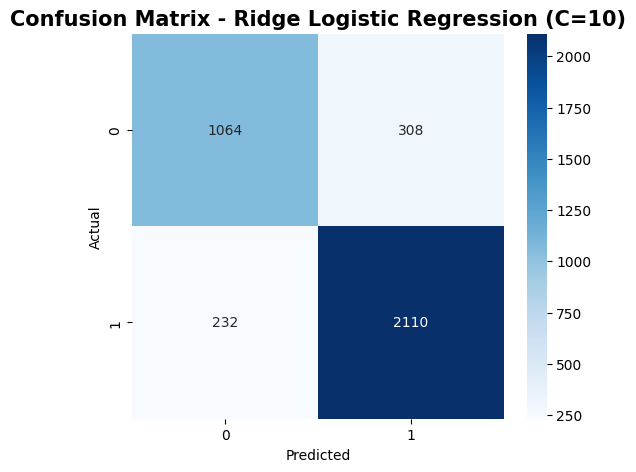

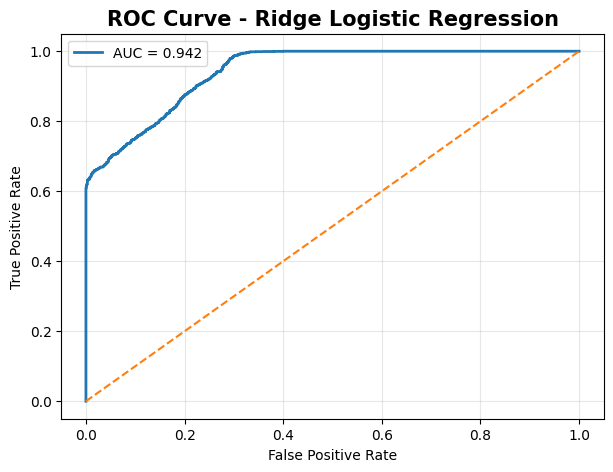



RIDGE COEFFICIENTS
                     Variable  Coefficient
3           mothers_age_gt_35       8.0566
12        health_worker_visit       4.3244
0        antenatal_visits_yes       3.2393
9      recieves_icds_benefits       3.1643
11             has_automobile       2.5960
1      institutional_delivery       2.3552
2                 birth_order       0.8574
8                wealth_index       0.8538
5              media_exposure       0.5870
4             residence_urban       0.4473
6            child_age_months       0.3199
7   highest_educational_level      -0.2134
10    facility_distance_issue      -3.1923


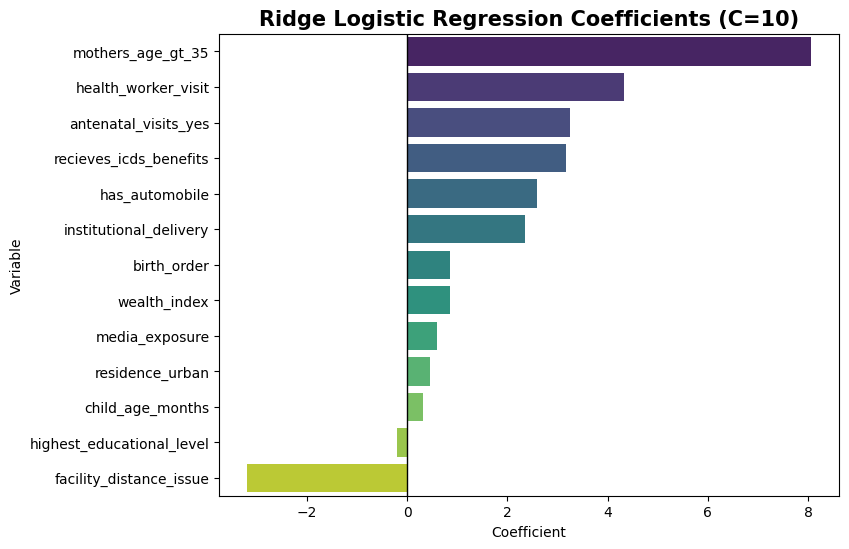

In [101]:
# =========================================================
# RIDGE LOGISTIC REGRESSION (C = 10)
# =========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# FIT MODEL
# =========================================================

ridge_model = LogisticRegression(
    penalty='l2',
    C=10,
    solver='liblinear',
    max_iter=1000,
    random_state=42
)

ridge_model.fit(X_train, y_train)

# =========================================================
# TRAINING PREDICTIONS
# =========================================================

train_pred = ridge_model.predict(X_train)

train_prob = ridge_model.predict_proba(X_train)[:,1]

# =========================================================
# TESTING PREDICTIONS
# =========================================================

test_pred = ridge_model.predict(X_test)

test_prob = ridge_model.predict_proba(X_test)[:,1]

# =========================================================
# TRAINING METRICS
# =========================================================

train_metrics = {

    'Accuracy': accuracy_score(y_train, train_pred),

    'Precision': precision_score(y_train, train_pred),

    'Recall': recall_score(y_train, train_pred),

    'F1 Score': f1_score(y_train, train_pred),

    'ROC AUC': roc_auc_score(y_train, train_prob)
}

# =========================================================
# TESTING METRICS
# =========================================================

test_metrics = {

    'Accuracy': accuracy_score(y_test, test_pred),

    'Precision': precision_score(y_test, test_pred),

    'Recall': recall_score(y_test, test_pred),

    'F1 Score': f1_score(y_test, test_pred),

    'ROC AUC': roc_auc_score(y_test, test_prob)
}

# =========================================================
# PERFORMANCE COMPARISON TABLE
# =========================================================

comparison = pd.DataFrame({

    'Metric': train_metrics.keys(),

    'Training': train_metrics.values(),

    'Testing': test_metrics.values()
})

comparison.iloc[:,1:] = comparison.iloc[:,1:].round(4)

print("\n")
print("="*60)
print("RIDGE LOGISTIC REGRESSION PERFORMANCE (C = 10)")
print("="*60)

print(comparison)

# =========================================================
# STYLED TABLE
# =========================================================

comparison.style\
    .background_gradient(
        cmap='Blues',
        subset=['Training', 'Testing']
    )\
    .set_caption(
        "Training vs Testing Performance"
    )

# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print("\n")
print("="*60)
print("CLASSIFICATION REPORT - TEST DATA")
print("="*60)

print(classification_report(
    y_test,
    test_pred
))

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    test_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Confusion Matrix - Ridge Logistic Regression (C=10)",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# =========================================================
# ROC CURVE
# =========================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    test_prob
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc_score(y_test, test_prob):.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.title(
    "ROC Curve - Ridge Logistic Regression",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# =========================================================
# COEFFICIENT TABLE
# =========================================================

ridge_coef = pd.DataFrame({

    'Variable': X_train.columns,

    'Coefficient': ridge_model.coef_[0]
})

ridge_coef['Coefficient'] = ridge_coef[
    'Coefficient'
].round(4)

ridge_coef = ridge_coef.sort_values(
    by='Coefficient',
    ascending=False
)

print("\n")
print("="*60)
print("RIDGE COEFFICIENTS")
print("="*60)

print(ridge_coef)

# =========================================================
# COEFFICIENT PLOT
# =========================================================

plt.figure(figsize=(8,6))

sns.barplot(
    x='Coefficient',
    y='Variable',
    data=ridge_coef,
    palette='viridis'
)

plt.title(
    "Ridge Logistic Regression Coefficients (C=10)",
    fontsize=15,
    fontweight='bold'
)

plt.axvline(
    0,
    color='black',
    linewidth=1
)

plt.show()

## RANDOM FOREST MODEL

In [56]:
"""
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV

# =========================================================
# PARAMETER GRID
# =========================================================

param_grid = {

    'n_estimators': [100, 200],

    'max_depth': [3, 5, 7, 10],

    'min_samples_split': [2, 5, 10],

    'min_samples_leaf': [1, 2, 4],

    'max_features': ['sqrt', 'log2']
}

# =========================================================
# BASE MODEL
# =========================================================

rf = RandomForestClassifier(
    random_state=42
)

# =========================================================
# GRID SEARCH
# =========================================================

grid_search = GridSearchCV(

    estimator=rf,

    param_grid=param_grid,

    cv=5,

    scoring='roc_auc',

    n_jobs=-1,

    verbose=1
)

grid_search.fit(X_train, y_train)


print("Best Parameters :")

print(grid_search.best_params_)

print()

print("Best ROC AUC :")

print(grid_search.best_score_)
"""

'\nfrom sklearn.ensemble import RandomForestClassifier\n\nfrom sklearn.model_selection import GridSearchCV\n\n# =========================================================\n# PARAMETER GRID\n# =========================================================\n\nparam_grid = {\n\n    \'n_estimators\': [100, 200],\n\n    \'max_depth\': [3, 5, 7, 10],\n\n    \'min_samples_split\': [2, 5, 10],\n\n    \'min_samples_leaf\': [1, 2, 4],\n\n    \'max_features\': [\'sqrt\', \'log2\']\n}\n\n# =========================================================\n# BASE MODEL\n# =========================================================\n\nrf = RandomForestClassifier(\n    random_state=42\n)\n\n# =========================================================\n# GRID SEARCH\n# =========================================================\n\ngrid_search = GridSearchCV(\n\n    estimator=rf,\n\n    param_grid=param_grid,\n\n    cv=5,\n\n    scoring=\'roc_auc\',\n\n    n_jobs=-1,\n\n    verbose=1\n)\n\ngrid_search.fit(X_train, y_trai

In [57]:
# =========================================================
# REFIT RANDOM FOREST USING BEST GRIDSEARCH PARAMETERS
# =========================================================

from sklearn.ensemble import RandomForestClassifier

# =========================================================
# CREATE FINAL MODEL USING BEST PARAMETERS
# =========================================================

rf_model = RandomForestClassifier(

    max_depth=10,

    max_features='sqrt',

    min_samples_leaf=1,

    min_samples_split=10,

    n_estimators=200,

    random_state=42
)

# =========================================================
# FIT MODEL
# =========================================================

rf_model.fit(X_train, y_train)

# =========================================================
# TRAINING PREDICTIONS
# =========================================================

train_pred = rf_model.predict(X_train)

train_prob = rf_model.predict_proba(X_train)[:,1]

# =========================================================
# TESTING PREDICTIONS
# =========================================================

test_pred = rf_model.predict(X_test)

test_prob = rf_model.predict_proba(X_test)[:,1]

# =========================================================
# IMPORT METRICS
# =========================================================

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# =========================================================
# TRAINING METRICS
# =========================================================

train_metrics = {

    'Accuracy': accuracy_score(y_train, train_pred),

    'Precision': precision_score(y_train, train_pred),

    'Recall': recall_score(y_train, train_pred),

    'F1 Score': f1_score(y_train, train_pred),

    'ROC AUC': roc_auc_score(y_train, train_prob)
}

# =========================================================
# TESTING METRICS
# =========================================================

test_metrics = {

    'Accuracy': accuracy_score(y_test, test_pred),

    'Precision': precision_score(y_test, test_pred),

    'Recall': recall_score(y_test, test_pred),

    'F1 Score': f1_score(y_test, test_pred),

    'ROC AUC': roc_auc_score(y_test, test_prob)
}

# =========================================================
# COMPARISON TABLE
# =========================================================

comparison = pd.DataFrame({

    'Metric': train_metrics.keys(),

    'Training': train_metrics.values(),

    'Testing': test_metrics.values()
})

comparison.iloc[:,1:] = comparison.iloc[:,1:].round(4)

# =========================================================
# DISPLAY RESULTS
# =========================================================

print("\n")
print("="*60)
print("RANDOM FOREST PERFORMANCE")
print("="*60)



# =========================================================
# STYLED TABLE
# =========================================================

comparison.style\
    .background_gradient(
        cmap='Blues',
        subset=['Training', 'Testing']
    )\
    .set_caption(
        "Random Forest: Training vs Testing Performance"
    )\
    .set_properties(**{
        'text-align': 'center',
        'font-size': '12px'
    })



RANDOM FOREST PERFORMANCE


,Metric,Training,Testing
0,Accuracy,0.892400,0.860500
1,Precision,0.870800,0.845500
2,Recall,0.973800,0.953000
3,F1 Score,0.919400,0.896000
4,ROC AUC,0.966500,0.936100


              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1372
           1       0.85      0.95      0.90      2342

    accuracy                           0.86      3714
   macro avg       0.87      0.83      0.84      3714
weighted avg       0.86      0.86      0.86      3714



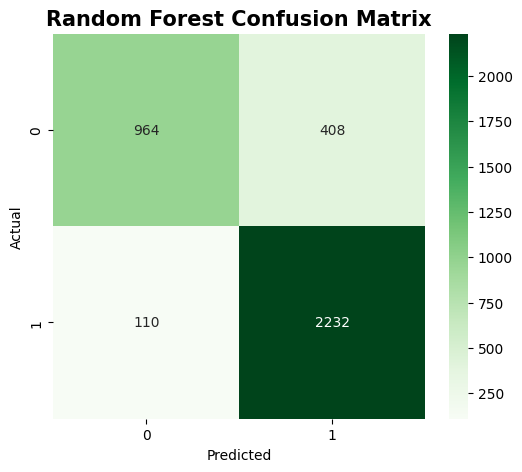

In [58]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    test_pred
))


from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    test_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    "Random Forest Confusion Matrix",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


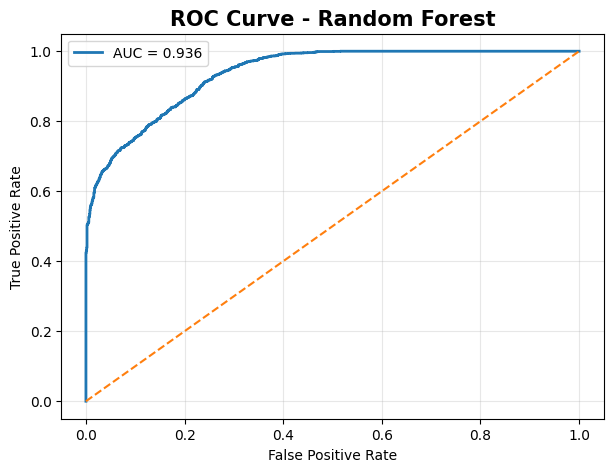

                     Variable  Importance
12        health_worker_visit      0.1980
0        antenatal_visits_yes      0.1322
9      recieves_icds_benefits      0.1053
10    facility_distance_issue      0.0964
8                wealth_index      0.0856
11             has_automobile      0.0805
6            child_age_months      0.0739
2                 birth_order      0.0685
3           mothers_age_gt_35      0.0662
1      institutional_delivery      0.0388
7   highest_educational_level      0.0232
5              media_exposure      0.0179
4             residence_urban      0.0136


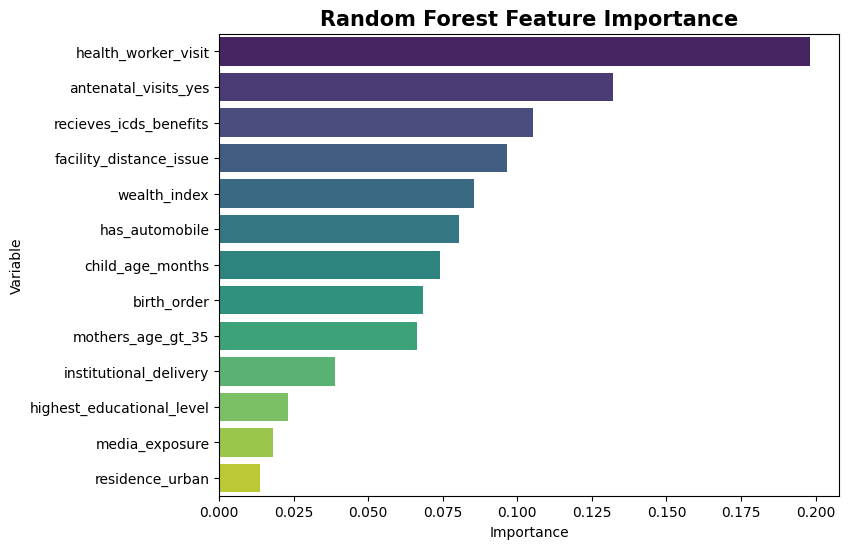

In [59]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    test_prob
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc_score(y_test, test_prob):.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.title(
    "ROC Curve - Random Forest",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

importance = pd.DataFrame({

    'Variable': X_train.columns,

    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance['Importance'] = importance[
    'Importance'
].round(4)

print(importance)


plt.figure(figsize=(8,6))

sns.barplot(
    x='Importance',
    y='Variable',
    data=importance,
    palette='viridis'
)

plt.title(
    "Random Forest Feature Importance",
    fontsize=15,
    fontweight='bold'
)

plt.show()

##  XGBOOST MODEL

In [60]:
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV

"""
# =========================================================
# XGBOOST PARAMETER GRID
# =========================================================

param_grid = {

    'n_estimators': [100, 200],

    'max_depth': [3, 5, 7],

    'learning_rate': [0.01, 0.05, 0.1],

    'subsample': [0.8, 1.0],

    'colsample_bytree': [0.8, 1.0],

    'gamma': [0, 0.1]
}



# =========================================================
# BASE MODEL
# =========================================================

xgb = XGBClassifier(

    objective='binary:logistic',

    eval_metric='logloss',

    random_state=42,

    use_label_encoder=False
)



# =========================================================
# GRID SEARCH
# =========================================================

grid_search = GridSearchCV(

    estimator=xgb,

    param_grid=param_grid,

    cv=5,

    scoring='roc_auc',

    n_jobs=-1,

    verbose=1
)

grid_search.fit(X_train, y_train)



print("Best Parameters :")

print(grid_search.best_params_)

print()

print("Best ROC AUC :")

print(grid_search.best_score_)

"""



'\n# =========================================================\n# XGBOOST PARAMETER GRID\n# =========================================================\n\nparam_grid = {\n\n    \'n_estimators\': [100, 200],\n\n    \'max_depth\': [3, 5, 7],\n\n    \'learning_rate\': [0.01, 0.05, 0.1],\n\n    \'subsample\': [0.8, 1.0],\n\n    \'colsample_bytree\': [0.8, 1.0],\n\n    \'gamma\': [0, 0.1]\n}\n\n\n\n# =========================================================\n# BASE MODEL\n# =========================================================\n\nxgb = XGBClassifier(\n\n    objective=\'binary:logistic\',\n\n    eval_metric=\'logloss\',\n\n    random_state=42,\n\n    use_label_encoder=False\n)\n\n\n\n# =========================================================\n# GRID SEARCH\n# =========================================================\n\ngrid_search = GridSearchCV(\n\n    estimator=xgb,\n\n    param_grid=param_grid,\n\n    cv=5,\n\n    scoring=\'roc_auc\',\n\n    n_jobs=-1,\n\n    verbose=1\n)\n\ngrid_searc

In [61]:
# =========================================================
# REFIT XGBOOST USING BEST GRIDSEARCH PARAMETERS
# =========================================================

from xgboost import XGBClassifier

# =========================================================
# FINAL XGBOOST MODEL
# =========================================================

xgb_model = XGBClassifier(

    objective='binary:logistic',

    eval_metric='logloss',

    colsample_bytree=1.0,

    gamma=0.1,

    learning_rate=0.1,

    max_depth=3,

    n_estimators=200,

    subsample=0.8,

    random_state=42,

    use_label_encoder=False
)

# =========================================================
# FIT MODEL
# =========================================================

xgb_model.fit(X_train, y_train)

# =========================================================
# TRAINING PREDICTIONS
# =========================================================

train_pred = xgb_model.predict(X_train)

train_prob = xgb_model.predict_proba(X_train)[:,1]

# =========================================================
# TESTING PREDICTIONS
# =========================================================

test_pred = xgb_model.predict(X_test)

test_prob = xgb_model.predict_proba(X_test)[:,1]

# =========================================================
# IMPORT METRICS
# =========================================================

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# =========================================================
# TRAINING METRICS
# =========================================================

train_metrics = {

    'Accuracy': accuracy_score(y_train, train_pred),

    'Precision': precision_score(y_train, train_pred),

    'Recall': recall_score(y_train, train_pred),

    'F1 Score': f1_score(y_train, train_pred),

    'ROC AUC': roc_auc_score(y_train, train_prob)
}

# =========================================================
# TESTING METRICS
# =========================================================

test_metrics = {

    'Accuracy': accuracy_score(y_test, test_pred),

    'Precision': precision_score(y_test, test_pred),

    'Recall': recall_score(y_test, test_pred),

    'F1 Score': f1_score(y_test, test_pred),

    'ROC AUC': roc_auc_score(y_test, test_prob)
}

# =========================================================
# COMPARISON TABLE
# =========================================================

comparison = pd.DataFrame({

    'Metric': train_metrics.keys(),

    'Training': train_metrics.values(),

    'Testing': test_metrics.values()
})

comparison.iloc[:,1:] = comparison.iloc[:,1:].round(4)

# =========================================================
# DISPLAY RESULTS
# =========================================================

print("\n")
print("="*60)
print("XGBOOST PERFORMANCE")
print("="*60)



# =========================================================
# STYLED TABLE
# =========================================================

comparison.style\
    .background_gradient(
        cmap='Purples',
        subset=['Training', 'Testing']
    )\
    .set_caption(
        "XGBoost: Training vs Testing Performance"
    )\
    .set_properties(**{
        'text-align': 'center',
        'font-size': '12px'
    })



XGBOOST PERFORMANCE


,Metric,Training,Testing
0,Accuracy,0.877200,0.863800
1,Precision,0.877400,0.868100
2,Recall,0.935900,0.924400
3,F1 Score,0.905700,0.895400
4,ROC AUC,0.954600,0.942700


              precision    recall  f1-score   support

           0       0.85      0.76      0.80      1372
           1       0.87      0.92      0.90      2342

    accuracy                           0.86      3714
   macro avg       0.86      0.84      0.85      3714
weighted avg       0.86      0.86      0.86      3714



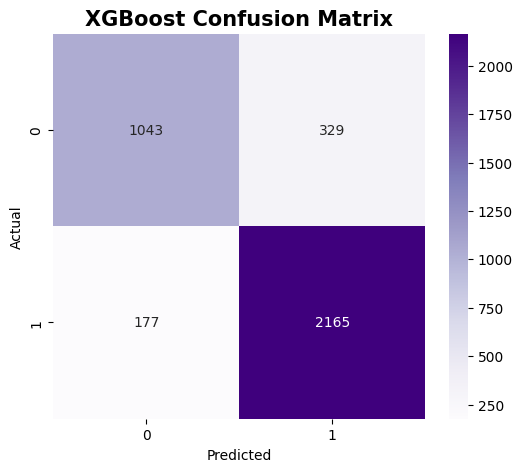

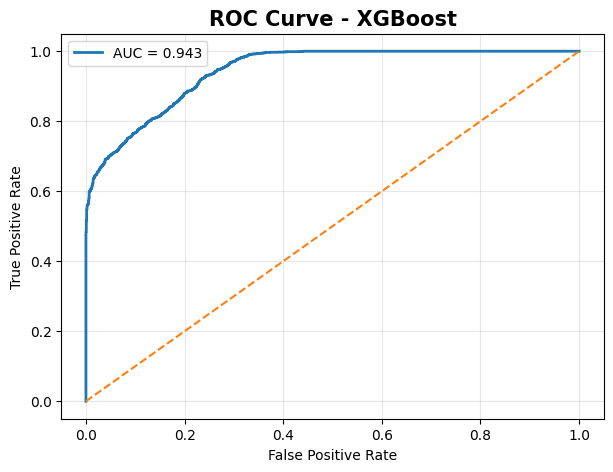

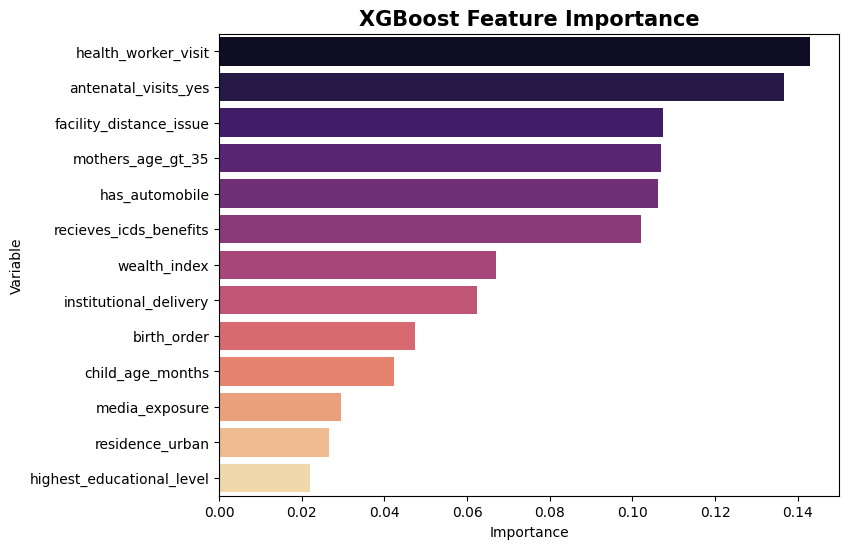

In [62]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    test_pred
))

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    test_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title(
    "XGBoost Confusion Matrix",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()



from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    test_prob
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc_score(y_test, test_prob):.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.title(
    "ROC Curve - XGBoost",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(alpha=0.3)

plt.show()


importance = pd.DataFrame({

    'Variable': X_train.columns,

    'Importance': xgb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance['Importance'] = importance[
    'Importance'
].round(4)

importance


plt.figure(figsize=(8,6))

sns.barplot(
    x='Importance',
    y='Variable',
    data=importance,
    palette='magma'
)

plt.title(
    "XGBoost Feature Importance",
    fontsize=15,
    fontweight='bold'
)

plt.show()



### KNN

In [63]:
# =========================================================
# K-NEAREST NEIGHBORS (KNN) CLASSIFIER
# =========================================================

# =========================================================
# IMPORT LIBRARIES
# =========================================================

from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt


"""
# =========================================================
# PIPELINE
# (Scaling is essential for KNN)
# =========================================================

pipeline = Pipeline([

    ('scaler', StandardScaler()),

    ('knn', KNeighborsClassifier())
])

# =========================================================
# PARAMETER GRID
# =========================================================

param_grid = {

    'knn__n_neighbors': [3, 5, 7, 9, 11],

    'knn__weights': ['uniform', 'distance'],

    'knn__metric': ["euclidean","hamming"]
}

# =========================================================
# GRID SEARCH
# =========================================================

grid_search = GridSearchCV(

    estimator=pipeline,

    param_grid=param_grid,

    cv=5,

    scoring='roc_auc',

    n_jobs=-1,

    verbose=1
)

grid_search.fit(X_train, y_train)

# =========================================================
# BEST PARAMETERS
# =========================================================

print("\n")
print("="*60)
print("BEST PARAMETERS")
print("="*60)

print(grid_search.best_params_)

print()

print("Best ROC AUC :")

print(round(grid_search.best_score_,4))
"""


'\n# =========================================================\n# PIPELINE\n# (Scaling is essential for KNN)\n# =========================================================\n\npipeline = Pipeline([\n\n    (\'scaler\', StandardScaler()),\n\n    (\'knn\', KNeighborsClassifier())\n])\n\n# =========================================================\n# PARAMETER GRID\n# =========================================================\n\nparam_grid = {\n\n    \'knn__n_neighbors\': [3, 5, 7, 9, 11],\n\n    \'knn__weights\': [\'uniform\', \'distance\'],\n\n    \'knn__metric\': ["euclidean","hamming"]\n}\n\n# =========================================================\n# GRID SEARCH\n# =========================================================\n\ngrid_search = GridSearchCV(\n\n    estimator=pipeline,\n\n    param_grid=param_grid,\n\n    cv=5,\n\n    scoring=\'roc_auc\',\n\n    n_jobs=-1,\n\n    verbose=1\n)\n\ngrid_search.fit(X_train, y_train)\n\n# =========================================================\n# 



KNN PERFORMANCE
      Metric  Training  Testing
0   Accuracy    0.8797   0.8508
1  Precision    0.8746   0.8528
2     Recall    0.9447   0.9227
3   F1 Score    0.9083   0.8864
4    ROC AUC    0.9520   0.9284


OVERFITTING CHECK
Training ROC AUC : 0.9520
Testing ROC AUC  : 0.9284
Difference        : 0.0235

No significant overfitting detected.


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.85      0.73      0.78      1372
           1       0.85      0.92      0.89      2342

    accuracy                           0.85      3714
   macro avg       0.85      0.83      0.83      3714
weighted avg       0.85      0.85      0.85      3714



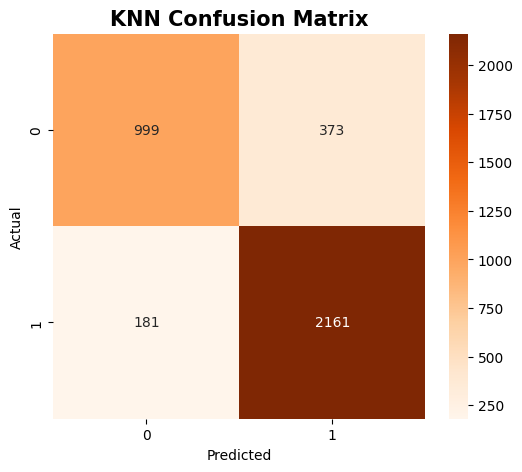

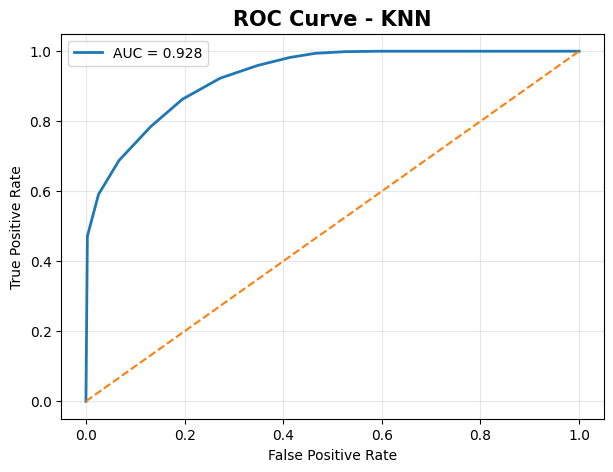

In [64]:
# =========================================================
# REFIT KNN USING BEST GRIDSEARCH PARAMETERS
# =========================================================

from sklearn.neighbors import KNeighborsClassifier

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

# =========================================================
# FINAL KNN MODEL
# =========================================================

knn_model = Pipeline([

    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(

        n_neighbors=11,

        metric='euclidean',

        weights='uniform'
    ))
])

# =========================================================
# FIT MODEL
# =========================================================

knn_model.fit(X_train, y_train)

# =========================================================
# TRAINING PREDICTIONS
# =========================================================

train_pred = knn_model.predict(X_train)

train_prob = knn_model.predict_proba(X_train)[:,1]

# =========================================================
# TESTING PREDICTIONS
# =========================================================

test_pred = knn_model.predict(X_test)

test_prob = knn_model.predict_proba(X_test)[:,1]

# =========================================================
# IMPORT METRICS
# =========================================================

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# =========================================================
# TRAINING METRICS
# =========================================================

train_metrics = {

    'Accuracy': accuracy_score(y_train, train_pred),

    'Precision': precision_score(y_train, train_pred),

    'Recall': recall_score(y_train, train_pred),

    'F1 Score': f1_score(y_train, train_pred),

    'ROC AUC': roc_auc_score(y_train, train_prob)
}

# =========================================================
# TESTING METRICS
# =========================================================

test_metrics = {

    'Accuracy': accuracy_score(y_test, test_pred),

    'Precision': precision_score(y_test, test_pred),

    'Recall': recall_score(y_test, test_pred),

    'F1 Score': f1_score(y_test, test_pred),

    'ROC AUC': roc_auc_score(y_test, test_prob)
}

# =========================================================
# COMPARISON TABLE
# =========================================================

comparison = pd.DataFrame({

    'Metric': train_metrics.keys(),

    'Training': train_metrics.values(),

    'Testing': test_metrics.values()
})

comparison.iloc[:,1:] = comparison.iloc[:,1:].round(4)

# =========================================================
# DISPLAY RESULTS
# =========================================================

print("\n")
print("="*60)
print("KNN PERFORMANCE")
print("="*60)

print(comparison)

# =========================================================
# STYLED TABLE
# =========================================================

comparison.style\
    .background_gradient(
        cmap='Oranges',
        subset=['Training', 'Testing']
    )\
    .set_caption(
        "KNN: Training vs Testing Performance"
    )\
    .set_properties(**{
        'text-align': 'center',
        'font-size': '12px'
    })

# =========================================================
# OVERFITTING CHECK
# =========================================================

print("\n")
print("="*60)
print("OVERFITTING CHECK")
print("="*60)

difference = abs(

    train_metrics['ROC AUC'] -

    test_metrics['ROC AUC']
)

print(f"Training ROC AUC : {train_metrics['ROC AUC']:.4f}")

print(f"Testing ROC AUC  : {test_metrics['ROC AUC']:.4f}")

print(f"Difference        : {difference:.4f}")

if difference < 0.03:

    print("\nNo significant overfitting detected.")

elif difference < 0.07:

    print("\nMild overfitting detected.")

else:

    print("\nSignificant overfitting detected.")

# =========================================================
# CLASSIFICATION REPORT
# =========================================================

from sklearn.metrics import classification_report

print("\n")
print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(classification_report(
    y_test,
    test_pred
))

# =========================================================
# CONFUSION MATRIX
# =========================================================

from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    test_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title(
    "KNN Confusion Matrix",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# =========================================================
# ROC CURVE
# =========================================================

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    test_prob
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc_score(y_test, test_prob):.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.title(
    "ROC Curve - KNN",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [65]:
"""
from sklearn.inspection import permutation_importance

# =========================================================
# PERMUTATION IMPORTANCE
# =========================================================

perm_importance = permutation_importance(

    knn_model,

    X_test,

    y_test,

    n_repeats=10,

    random_state=42,

    scoring='roc_auc'
)

# =========================================================
# CREATE DATAFRAME
# =========================================================

perm_df = pd.DataFrame({

    'Variable': X_test.columns,

    'Importance': perm_importance.importances_mean
})

# =========================================================
# SORT
# =========================================================

perm_df = perm_df.sort_values(

    by='Importance',

    ascending=False
)

perm_df['Importance'] = perm_df[
    'Importance'
].round(4)

# =========================================================
# DISPLAY
# =========================================================

print("\n")
print("="*60)
print("PERMUTATION FEATURE IMPORTANCE - KNN")
print("="*60)

print(perm_df)

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(8,6))

sns.barplot(

    x='Importance',

    y='Variable',

    data=perm_df,

    palette='Oranges'
)

plt.title(

    "Permutation Feature Importance - KNN",

    fontsize=15,

    fontweight='bold'
)

plt.xlabel("Mean Decrease in ROC-AUC")

plt.ylabel("Variables")

plt.tight_layout()

plt.show()
"""


'\nfrom sklearn.inspection import permutation_importance\n\n# =========================================================\n# PERMUTATION IMPORTANCE\n# =========================================================\n\nperm_importance = permutation_importance(\n\n    knn_model,\n\n    X_test,\n\n    y_test,\n\n    n_repeats=10,\n\n    random_state=42,\n\n    scoring=\'roc_auc\'\n)\n\n# =========================================================\n# CREATE DATAFRAME\n# =========================================================\n\nperm_df = pd.DataFrame({\n\n    \'Variable\': X_test.columns,\n\n    \'Importance\': perm_importance.importances_mean\n})\n\n# =========================================================\n# SORT\n# =========================================================\n\nperm_df = perm_df.sort_values(\n\n    by=\'Importance\',\n\n    ascending=False\n)\n\nperm_df[\'Importance\'] = perm_df[\n    \'Importance\'\n].round(4)\n\n# =========================================================\n# DI

In [66]:
"""
k_values = range(1,21)

train_scores = []
test_scores = []

for k in k_values:

    knn = Pipeline([

        ('knn', KNeighborsClassifier(n_neighbors=k,metric="hamming"))
    ])

    knn.fit(X_train, y_train)

    train_scores.append(
        knn.score(X_train, y_train)
    )

    test_scores.append(
        knn.score(X_test, y_test)
    )

# Plot
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    train_scores,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    k_values,
    test_scores,
    marker='o',
    label='Testing Accuracy'
)

plt.title(
    "KNN Performance Across Different K Values",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Number of Neighbors (K)")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(alpha=0.3)

plt.show()
"""

'\nk_values = range(1,21)\n\ntrain_scores = []\ntest_scores = []\n\nfor k in k_values:\n\n    knn = Pipeline([\n\n        (\'knn\', KNeighborsClassifier(n_neighbors=k,metric="hamming"))\n    ])\n\n    knn.fit(X_train, y_train)\n\n    train_scores.append(\n        knn.score(X_train, y_train)\n    )\n\n    test_scores.append(\n        knn.score(X_test, y_test)\n    )\n\n# Plot\nplt.figure(figsize=(8,5))\n\nplt.plot(\n    k_values,\n    train_scores,\n    marker=\'o\',\n    label=\'Training Accuracy\'\n)\n\nplt.plot(\n    k_values,\n    test_scores,\n    marker=\'o\',\n    label=\'Testing Accuracy\'\n)\n\nplt.title(\n    "KNN Performance Across Different K Values",\n    fontsize=15,\n    fontweight=\'bold\'\n)\n\nplt.xlabel("Number of Neighbors (K)")\n\nplt.ylabel("Accuracy")\n\nplt.legend()\n\nplt.grid(alpha=0.3)\n\nplt.show()\n'

###  SVM

In [67]:
# =========================================================
# SUPPORT VECTOR MACHINE (SVM) CLASSIFIER
# =========================================================

# =========================================================
# IMPORT LIBRARIES
# =========================================================

from sklearn.svm import SVC

from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt

"""
# =========================================================
# PIPELINE
# (Scaling is essential for SVM)
# =========================================================

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        probability=True,
        random_state=42
    ))
])

# =========================================================
# PARAMETER GRID
# =========================================================

param_grid = {

    'svm__C': [0.1, 1, 10],

    'svm__kernel': ['linear', 'rbf'],

    'svm__gamma': ['scale', 'auto']
}

# =========================================================
# GRID SEARCH
# =========================================================

grid_search = GridSearchCV(

    estimator=pipeline,

    param_grid=param_grid,

    cv=5,

    scoring='roc_auc',

    n_jobs=-1,

    verbose=1
)

grid_search.fit(X_train, y_train)

# =========================================================
# BEST PARAMETERS
# =========================================================

print("\n")
print("="*60)
print("BEST PARAMETERS")
print("="*60)

print(grid_search.best_params_)

print()

print("Best ROC AUC :")

print(round(grid_search.best_score_,4))
"""

'\n# =========================================================\n# PIPELINE\n# (Scaling is essential for SVM)\n# =========================================================\n\npipeline = Pipeline([\n    (\'scaler\', StandardScaler()),\n    (\'svm\', SVC(\n        probability=True,\n        random_state=42\n    ))\n])\n\n# =========================================================\n# PARAMETER GRID\n# =========================================================\n\nparam_grid = {\n\n    \'svm__C\': [0.1, 1, 10],\n\n    \'svm__kernel\': [\'linear\', \'rbf\'],\n\n    \'svm__gamma\': [\'scale\', \'auto\']\n}\n\n# =========================================================\n# GRID SEARCH\n# =========================================================\n\ngrid_search = GridSearchCV(\n\n    estimator=pipeline,\n\n    param_grid=param_grid,\n\n    cv=5,\n\n    scoring=\'roc_auc\',\n\n    n_jobs=-1,\n\n    verbose=1\n)\n\ngrid_search.fit(X_train, y_train)\n\n# ================================================



SVM PERFORMANCE
      Metric  Training  Testing
0   Accuracy    0.8612   0.8605
1  Precision    0.8577   0.8588
2     Recall    0.9350   0.9321
3   F1 Score    0.8947   0.8939
4    ROC AUC    0.9441   0.9420


OVERFITTING CHECK
Training ROC AUC : 0.9441
Testing ROC AUC  : 0.9420
Difference        : 0.0021

No significant overfitting detected.


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.86      0.74      0.80      1372
           1       0.86      0.93      0.89      2342

    accuracy                           0.86      3714
   macro avg       0.86      0.84      0.85      3714
weighted avg       0.86      0.86      0.86      3714



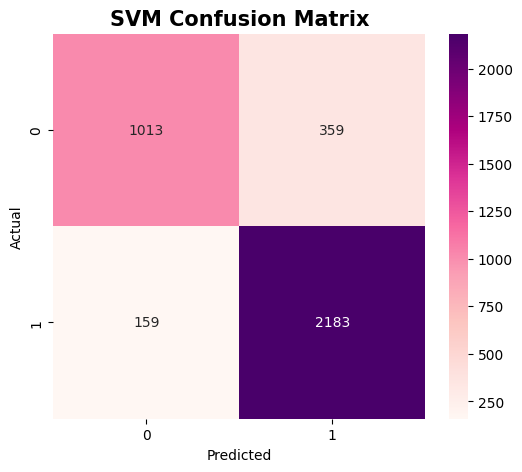

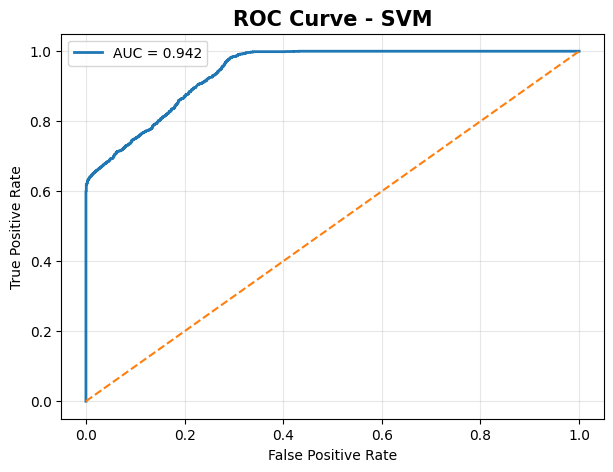

In [68]:
# =========================================================
# REFIT SVM USING BEST GRIDSEARCH PARAMETERS
# =========================================================

from sklearn.svm import SVC

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

# =========================================================
# FINAL SVM MODEL
# =========================================================

svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(

        C=10,

        kernel='linear',

        gamma='scale',

        probability=True,

        random_state=42
    ))
])

# =========================================================
# FIT MODEL
# =========================================================

svm_model.fit(X_train, y_train)

# =========================================================
# TRAINING PREDICTIONS
# =========================================================

train_pred = svm_model.predict(X_train)

train_prob = svm_model.predict_proba(X_train)[:,1]

# =========================================================
# TESTING PREDICTIONS
# =========================================================

test_pred = svm_model.predict(X_test)

test_prob = svm_model.predict_proba(X_test)[:,1]

# =========================================================
# IMPORT METRICS
# =========================================================

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# =========================================================
# TRAINING METRICS
# =========================================================

train_metrics = {

    'Accuracy': accuracy_score(y_train, train_pred),

    'Precision': precision_score(y_train, train_pred),

    'Recall': recall_score(y_train, train_pred),

    'F1 Score': f1_score(y_train, train_pred),

    'ROC AUC': roc_auc_score(y_train, train_prob)
}

# =========================================================
# TESTING METRICS
# =========================================================

test_metrics = {

    'Accuracy': accuracy_score(y_test, test_pred),

    'Precision': precision_score(y_test, test_pred),

    'Recall': recall_score(y_test, test_pred),

    'F1 Score': f1_score(y_test, test_pred),

    'ROC AUC': roc_auc_score(y_test, test_prob)
}

# =========================================================
# PERFORMANCE COMPARISON TABLE
# =========================================================

comparison = pd.DataFrame({

    'Metric': train_metrics.keys(),

    'Training': train_metrics.values(),

    'Testing': test_metrics.values()
})

comparison.iloc[:,1:] = comparison.iloc[:,1:].round(4)

# =========================================================
# DISPLAY RESULTS
# =========================================================

print("\n")
print("="*60)
print("SVM PERFORMANCE")
print("="*60)

print(comparison)

# =========================================================
# STYLED TABLE
# =========================================================

comparison.style\
    .background_gradient(
        cmap='RdPu',
        subset=['Training', 'Testing']
    )\
    .set_caption(
        "SVM: Training vs Testing Performance"
    )\
    .set_properties(**{
        'text-align': 'center',
        'font-size': '12px'
    })

# =========================================================
# OVERFITTING CHECK
# =========================================================

print("\n")
print("="*60)
print("OVERFITTING CHECK")
print("="*60)

difference = abs(

    train_metrics['ROC AUC'] -

    test_metrics['ROC AUC']
)

print(f"Training ROC AUC : {train_metrics['ROC AUC']:.4f}")

print(f"Testing ROC AUC  : {test_metrics['ROC AUC']:.4f}")

print(f"Difference        : {difference:.4f}")

if difference < 0.03:

    print("\nNo significant overfitting detected.")

elif difference < 0.07:

    print("\nMild overfitting detected.")

else:

    print("\nSignificant overfitting detected.")

# =========================================================
# CLASSIFICATION REPORT
# =========================================================

from sklearn.metrics import classification_report

print("\n")
print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(classification_report(
    y_test,
    test_pred
))

# =========================================================
# CONFUSION MATRIX
# =========================================================

from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    test_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='RdPu'
)

plt.title(
    "SVM Confusion Matrix",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# =========================================================
# ROC CURVE
# =========================================================

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    test_prob
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc_score(y_test, test_prob):.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.title(
    "ROC Curve - SVM",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [69]:
"""
from sklearn.inspection import permutation_importance

# =========================================================
# PERMUTATION IMPORTANCE
# =========================================================

perm_importance = permutation_importance(

    svm_model,

    X_test,

    y_test,

    n_repeats=20,

    random_state=42,

    scoring='roc_auc'
)

# =========================================================
# CREATE DATAFRAME
# =========================================================

perm_df = pd.DataFrame({

    'Variable': X_test.columns,

    'Importance': perm_importance.importances_mean
})

# =========================================================
# SORT
# =========================================================

perm_df = perm_df.sort_values(

    by='Importance',

    ascending=False
)

perm_df['Importance'] = perm_df[
    'Importance'
].round(4)

# =========================================================
# DISPLAY
# =========================================================

print("\n")
print("="*60)
print("PERMUTATION FEATURE IMPORTANCE - SVM")
print("="*60)

print(perm_df)

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(8,6))

sns.barplot(

    x='Importance',

    y='Variable',

    data=perm_df,

    palette='RdPu'
)

plt.title(

    "Permutation Feature Importance - SVM",

    fontsize=15,

    fontweight='bold'
)

plt.xlabel("Mean Decrease in ROC-AUC")

plt.ylabel("Variables")

plt.tight_layout()

plt.show()
"""

'\nfrom sklearn.inspection import permutation_importance\n\n# =========================================================\n# PERMUTATION IMPORTANCE\n# =========================================================\n\nperm_importance = permutation_importance(\n\n    svm_model,\n\n    X_test,\n\n    y_test,\n\n    n_repeats=20,\n\n    random_state=42,\n\n    scoring=\'roc_auc\'\n)\n\n# =========================================================\n# CREATE DATAFRAME\n# =========================================================\n\nperm_df = pd.DataFrame({\n\n    \'Variable\': X_test.columns,\n\n    \'Importance\': perm_importance.importances_mean\n})\n\n# =========================================================\n# SORT\n# =========================================================\n\nperm_df = perm_df.sort_values(\n\n    by=\'Importance\',\n\n    ascending=False\n)\n\nperm_df[\'Importance\'] = perm_df[\n    \'Importance\'\n].round(4)\n\n# =========================================================\n# DI

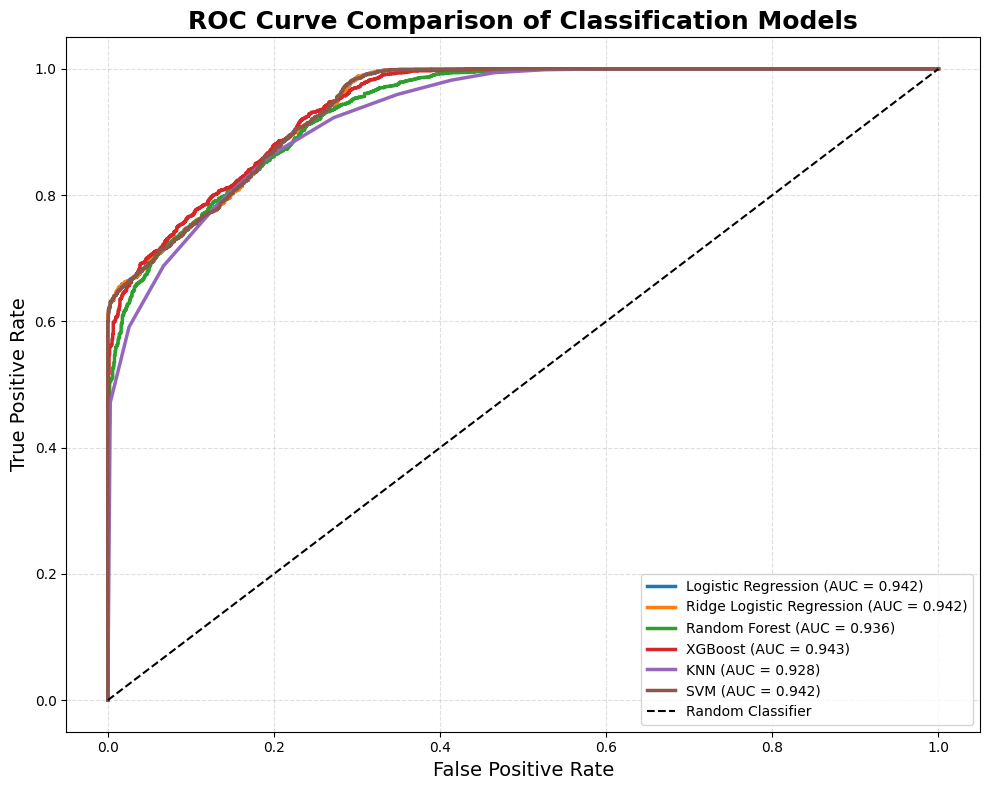



ROC-AUC COMPARISON
                       Model  ROC AUC
3                    XGBoost   0.9427
0        Logistic Regression   0.9421
1  Ridge Logistic Regression   0.9421
5                        SVM   0.9420
2              Random Forest   0.9361
4                        KNN   0.9284


,Model,ROC AUC
3,XGBoost,0.942700
0,Logistic Regression,0.942100
1,Ridge Logistic Regression,0.942100
5,SVM,0.942000
2,Random Forest,0.936100
4,KNN,0.928400


In [70]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# =========================================================
# LOGISTIC REGRESSION PROBABILITIES
# =========================================================

logit_prob = result.predict(X_test_sm)

# =========================================================
# RIDGE PROBABILITIES
# =========================================================

ridge_prob = ridge_model.predict_proba(X_test)[:,1]

# =========================================================
# RANDOM FOREST PROBABILITIES
# =========================================================

rf_prob = rf_model.predict_proba(X_test)[:,1]

# =========================================================
# XGBOOST PROBABILITIES
# =========================================================

xgb_prob = xgb_model.predict_proba(X_test)[:,1]

# =========================================================
# KNN PROBABILITIES
# =========================================================

knn_prob = knn_model.predict_proba(X_test)[:,1]

# =========================================================
# SVM PROBABILITIES
# =========================================================

svm_prob = svm_model.predict_proba(X_test)[:,1]

# =========================================================
# ROC CURVES
# =========================================================

# Logistic Regression
logit_fpr, logit_tpr, _ = roc_curve(
    y_test,
    logit_prob
)

# Ridge Logistic Regression
ridge_fpr, ridge_tpr, _ = roc_curve(
    y_test,
    ridge_prob
)

# Random Forest
rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_prob
)

# XGBoost
xgb_fpr, xgb_tpr, _ = roc_curve(
    y_test,
    xgb_prob
)

# KNN
knn_fpr, knn_tpr, _ = roc_curve(
    y_test,
    knn_prob
)

# SVM
svm_fpr, svm_tpr, _ = roc_curve(
    y_test,
    svm_prob
)

# =========================================================
# ROC-AUC SCORES
# =========================================================

logit_auc = roc_auc_score(
    y_test,
    logit_prob
)

ridge_auc = roc_auc_score(
    y_test,
    ridge_prob
)

rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

xgb_auc = roc_auc_score(
    y_test,
    xgb_prob
)

knn_auc = roc_auc_score(
    y_test,
    knn_prob
)

svm_auc = roc_auc_score(
    y_test,
    svm_prob
)

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(10,8))

# =========================================================
# LOGISTIC REGRESSION
# =========================================================

plt.plot(

    logit_fpr,

    logit_tpr,

    linewidth=2.5,

    label=f'Logistic Regression (AUC = {logit_auc:.3f})'
)

# =========================================================
# RIDGE LOGISTIC REGRESSION
# =========================================================

plt.plot(

    ridge_fpr,

    ridge_tpr,

    linewidth=2.5,

    label=f'Ridge Logistic Regression (AUC = {ridge_auc:.3f})'
)

# =========================================================
# RANDOM FOREST
# =========================================================

plt.plot(

    rf_fpr,

    rf_tpr,

    linewidth=2.5,

    label=f'Random Forest (AUC = {rf_auc:.3f})'
)

# =========================================================
# XGBOOST
# =========================================================

plt.plot(

    xgb_fpr,

    xgb_tpr,

    linewidth=2.5,

    label=f'XGBoost (AUC = {xgb_auc:.3f})'
)

# =========================================================
# KNN
# =========================================================

plt.plot(

    knn_fpr,

    knn_tpr,

    linewidth=2.5,

    label=f'KNN (AUC = {knn_auc:.3f})'
)

# =========================================================
# SVM
# =========================================================

plt.plot(

    svm_fpr,

    svm_tpr,

    linewidth=2.5,

    label=f'SVM (AUC = {svm_auc:.3f})'
)

# =========================================================
# RANDOM CLASSIFIER LINE
# =========================================================

plt.plot(

    [0,1],

    [0,1],

    linestyle='--',

    color='black',

    linewidth=1.5,

    label='Random Classifier'
)

# =========================================================
# TITLE & LABELS
# =========================================================

plt.title(

    "ROC Curve Comparison of Classification Models",

    fontsize=18,

    fontweight='bold'
)

plt.xlabel(

    "False Positive Rate",

    fontsize=14
)

plt.ylabel(

    "True Positive Rate",

    fontsize=14
)

# =========================================================
# LEGEND
# =========================================================

plt.legend(

    loc='lower right',

    fontsize=10
)

# =========================================================
# GRID
# =========================================================

plt.grid(

    linestyle='--',

    alpha=0.4
)

# =========================================================
# LAYOUT
# =========================================================

plt.tight_layout()

# =========================================================
# SHOW
# =========================================================

plt.show()

# =========================================================
# ROC-AUC SUMMARY TABLE
# =========================================================

roc_summary = pd.DataFrame({

    'Model': [

        'Logistic Regression',

        'Ridge Logistic Regression',

        'Random Forest',

        'XGBoost',

        'KNN',

        'SVM'
    ],

    'ROC AUC': [

        round(logit_auc,4),

        round(ridge_auc,4),

        round(rf_auc,4),

        round(xgb_auc,4),

        round(knn_auc,4),

        round(svm_auc,4)
    ]
})

roc_summary = roc_summary.sort_values(
    by='ROC AUC',
    ascending=False
)

print("\n")
print("="*65)
print("ROC-AUC COMPARISON")
print("="*65)

print(roc_summary)

# =========================================================
# STYLED TABLE
# =========================================================

roc_summary.style\
    .background_gradient(
        cmap='coolwarm',
        subset=['ROC AUC']
    )\
    .set_caption(
        "ROC-AUC Comparison of Classification Models"
    )\
    .set_properties(**{
        'text-align': 'center',
        'font-size': '12px'
    })

In [71]:
from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    cohen_kappa_score
)

import pandas as pd

# =========================================================
# LOGISTIC REGRESSION
# =========================================================

logit_prob = result.predict(X_test_sm)

logit_pred = (logit_prob >= 0.5).astype(int)

# =========================================================
# STORE ALL MODELS
# =========================================================

models = {

    'Logistic Regression': (

        logit_pred,
        logit_prob
    ),

    'Ridge Logistic Regression': (

        ridge_model.predict(X_test),
        ridge_model.predict_proba(X_test)[:,1]
    ),

    'Random Forest': (

        rf_model.predict(X_test),
        rf_model.predict_proba(X_test)[:,1]
    ),

    'XGBoost': (

        xgb_model.predict(X_test),
        xgb_model.predict_proba(X_test)[:,1]
    ),

    'KNN': (

        knn_model.predict(X_test),
        knn_model.predict_proba(X_test)[:,1]
    ),

    'SVM': (

        svm_model.predict(X_test),
        svm_model.predict_proba(X_test)[:,1]
    )
}

# =========================================================
# EMPTY LIST
# =========================================================

rows = []

# =========================================================
# LOOP THROUGH MODELS
# =========================================================

for model_name, (y_pred, y_prob) in models.items():

    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    sensitivity = recall_score(y_test, y_pred)

    specificity = tn / (tn + fp)

    f1 = f1_score(y_test, y_pred)

    auc = roc_auc_score(y_test, y_prob)

    kappa = cohen_kappa_score(y_test, y_pred)

    rows.append({

        'Model': model_name,

        'Accuracy (%)':
            round(accuracy * 100, 2),

        'Precision (%)':
            round(precision * 100, 2),

        'Sensitivity (%)':
            round(sensitivity * 100, 2),

        'Specificity (%)':
            round(specificity * 100, 2),

        'F1-Score (%)':
            round(f1 * 100, 2),

        'ROC-AUC (%)':
            round(auc * 100, 2),

        'Kappa (%)':
            round(kappa * 100, 2)
    })

# =========================================================
# CREATE FINAL TABLE
# =========================================================

comparison_table = pd.DataFrame(rows)

# =========================================================
# SORT BY ROC-AUC
# =========================================================

comparison_table = comparison_table.sort_values(

    by='ROC-AUC (%)',

    ascending=False
)

# =========================================================
# DISPLAY TABLE
# =========================================================

print("\n")
print("="*120)
print("COMPARISON OF CLASSIFICATION MODELS")
print("="*120)

display(comparison_table)

# =========================================================
# STYLED TABLE
# =========================================================

comparison_table.style\
    .background_gradient(
        cmap='Blues',
        subset=[
            'Accuracy (%)',
            'Precision (%)',
            'Sensitivity (%)',
            'Specificity (%)',
            'F1-Score (%)',
            'ROC-AUC (%)',
            'Kappa (%)'
        ]
    )\
    .set_caption(
        "Performance Comparison of Machine Learning Models"
    )\
    .set_properties(**{
        'text-align': 'center',
        'font-size': '12px'
    })



COMPARISON OF CLASSIFICATION MODELS


,Model,Accuracy (%),Precision (%),Sensitivity (%),Specificity (%),F1-Score (%),ROC-AUC (%),Kappa (%)
3,XGBoost,86.38,86.81,92.44,76.02,89.54,94.27,70.07
0,Logistic Regression,85.49,87.33,90.05,77.70,88.67,94.21,68.50
1,Ridge Logistic Regression,85.38,87.06,90.22,77.11,88.61,94.21,68.21
5,SVM,86.05,85.88,93.21,73.83,89.39,94.20,69.13
2,Random Forest,86.05,84.55,95.30,70.26,89.60,93.61,68.65
4,KNN,85.08,85.28,92.27,72.81,88.64,92.84,67.03


,Model,Accuracy (%),Precision (%),Sensitivity (%),Specificity (%),F1-Score (%),ROC-AUC (%),Kappa (%)
3,XGBoost,86.380000,86.810000,92.440000,76.020000,89.540000,94.270000,70.070000
0,Logistic Regression,85.490000,87.330000,90.050000,77.700000,88.670000,94.210000,68.500000
1,Ridge Logistic Regression,85.380000,87.060000,90.220000,77.110000,88.610000,94.210000,68.210000
5,SVM,86.050000,85.880000,93.210000,73.830000,89.390000,94.200000,69.130000
2,Random Forest,86.050000,84.550000,95.300000,70.260000,89.600000,93.610000,68.650000
4,KNN,85.080000,85.280000,92.270000,72.810000,88.640000,92.840000,67.030000


In [72]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# =========================================================
# EMPTY LIST
# =========================================================

cm_rows = []

# =========================================================
# LOOP THROUGH ALL MODELS
# =========================================================

for model_name, (y_pred, y_prob) in models.items():

    # Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    # Store results
    cm_rows.append({

        'Model': model_name,

        'True Positive (TP)': tp,

        'True Negative (TN)': tn,

        'False Positive (FP)': fp,

        'False Negative (FN)': fn
    })

# =========================================================
# CREATE TABLE
# =========================================================

confusion_table = pd.DataFrame(cm_rows)

# =========================================================
# DISPLAY TABLE
# =========================================================

print("\n")
print("="*100)
print("CONFUSION MATRIX COMPARISON TABLE")
print("="*100)

display(confusion_table)

# =========================================================
# STYLED TABLE
# =========================================================

confusion_table.style\
    .background_gradient(
        cmap='Greens',
        subset=[
            'True Positive (TP)',
            'True Negative (TN)'
        ]
    )\
    .background_gradient(
        cmap='Reds',
        subset=[
            'False Positive (FP)',
            'False Negative (FN)'
        ]
    )\
    .set_caption(
        "Confusion Matrix Comparison of Machine Learning Models"
    )\
    .set_properties(**{
        'text-align': 'center',
        'font-size': '12px'
    })



CONFUSION MATRIX COMPARISON TABLE


,Model,True Positive (TP),True Negative (TN),False Positive (FP),False Negative (FN)
0,Logistic Regression,2109,1066,306,233
1,Ridge Logistic Regression,2113,1058,314,229
2,Random Forest,2232,964,408,110
3,XGBoost,2165,1043,329,177
4,KNN,2161,999,373,181
5,SVM,2183,1013,359,159


,Model,True Positive (TP),True Negative (TN),False Positive (FP),False Negative (FN)
0,Logistic Regression,2109,1066,306,233
1,Ridge Logistic Regression,2113,1058,314,229
2,Random Forest,2232,964,408,110
3,XGBoost,2165,1043,329,177
4,KNN,2161,999,373,181
5,SVM,2183,1013,359,159
